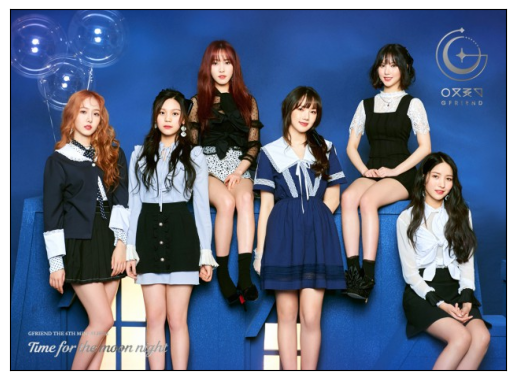

In [1]:
import matplotlib.pyplot as plt
from PIL import Image

PIL_img = Image.open('./data/fig/001.jpg')

plt.figure()
plt.imshow(PIL_img)
plt.xticks([])
plt.yticks([])
plt.show()

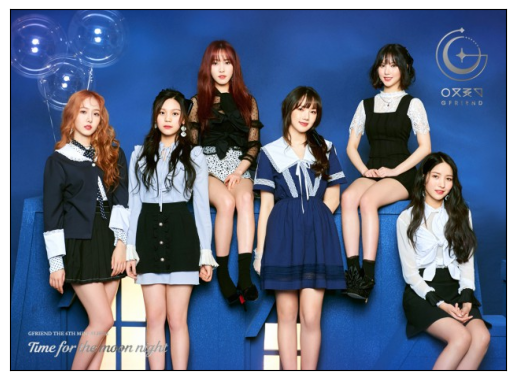

In [2]:
import matplotlib.pyplot as plt
from skimage import io

SK_img = io.imread('./data/fig/001.jpg')

plt.figure()
plt.imshow(SK_img)
plt.xticks([])
plt.yticks([])
plt.show()

In [3]:
import cv2
cv2.__version__

'5.0.0'

cv2 : ['ACCESS_FAST', 'ACCESS_MASK', 'ACCESS_READ', 'ACCESS_RW', 'ACCESS_WRITE', 'ADAPTIVE_THRESH_GAUSSIAN_C', 'ADAPTIVE_THRESH_MEAN_C', 'ALGO_HINT_ACCURATE', 'ALGO_HINT_APPROX', 'ALGO_HINT_DEFAULT', 'ALIKED', 'ALIKED_Params', 'ALIKED_create', 'ANNINDEX_DIST_ANGULAR', 'ANNINDEX_DIST_DOTPRODUCT', 'ANNINDEX_DIST_EUCLIDEAN', 'ANNINDEX_DIST_HAMMING', 'ANNINDEX_DIST_MANHATTAN', 'ANNIndex', 'ANNIndex_DIST_ANGULAR', 'ANNIndex_DIST_DOTPRODUCT', 'ANNIndex_DIST_EUCLIDEAN', 'ANNIndex_DIST_HAMMING', 'ANNIndex_DIST_MANHATTAN', 'ANNIndex_create', 'AffineFeature', 'AffineFeature_create', 'Algorithm', 'AlignExposures', 'AlignMTB', 'Animation', 'AsyncArray', 'BFMatcher', 'BFMatcher_create', 'BORDER_CONSTANT', 'BORDER_DEFAULT', 'BORDER_ISOLATED', 'BORDER_REFLECT', 'BORDER_REFLECT101', 'BORDER_REFLECT_101', 'BORDER_REPLICATE', 'BORDER_TRANSPARENT', 'BORDER_WRAP', 'BackgroundSubtractor', 'BackgroundSubtractorKNN', 'BackgroundSubtractorMOG2', 'CALIB_CB_ACCURACY', 'CALIB_CB_ADAPTIVE_THRESH', 'CALIB_CB_ASYMM

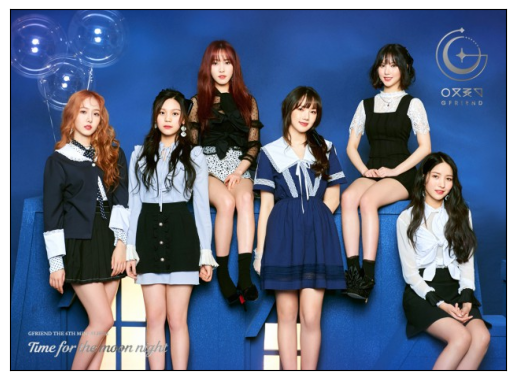

In [4]:
import matplotlib.pyplot as plt
import cv2

print(f'cv2 : {dir(cv2)}')
CV_BGR = cv2.imread('./data/fig/001.jpg')

print(f'CV_BGR : {dir(CV_BGR)}')
RGB_img = cv2.cvtColor(CV_BGR, cv2.COLOR_BGR2RGB) # opencv : default - BGR -> RGB로 바꿔주는 작업 필요

plt.figure()
plt.imshow(RGB_img)
plt.xticks([])
plt.yticks([])
plt.show()

In [5]:
import cv2
import numpy as np

# 테스트용 간단한 이미지 직접 생성
# 3x4 크기의 컬러 이미지 (BGR)
img = np.array([
    [[255, 0, 0],   [0, 255, 0],   [0, 0, 255],   [255, 255, 0]],
    [[0, 255, 255], [255, 0, 255], [128, 128, 0], [0, 128, 255]],
    [[50, 100, 150],[200, 150, 100],[30, 200, 30], [100, 50, 200]]
], dtype=np.uint8)
print(img)
print()

print('=== 이미지 배열 기본 정보 ===')
print(f'shape (높이x너비x채널) : {img.shape}') # (3, 4, 3)
print(f'dtype (데이터 타입) : {img.dtype}') # uint8
print(f'size  (전체 픽셀 수) : {img.size}') # 36
print(f'ndim  (차원 수) : {img.ndim}') # 3

# 채널 분리
B, G, R = cv2.split(img) # 또는 img[:,:,0], img[:,:,1], img[:,:,2]
print(f'\nBlue 채널:\n{B}')
print(f'Green 채널:\n{G}')
print(f'Red 채널:\n{R}')

# 특정 픽셀 값 접근
px = img[0, 0]  # 0행 0열 픽셀
print(f'\n[0,0] 픽셀 BGR: {px}')  # [255 0 0] -> 파란색

# 특정 채널 값만 접근
print(f'[1,2] 픽셀 B채널: {img[1,2,0]}')  # B값만

# 영역(ROI) 선택
# a = img[0:2]
# print(f'a : {a}')
# b = img[1:3]
# print(f'b : {b}')

roi = img[0:2, 1:3]  # 0~1행, 1~2열 영역
print(roi)
print(f'\nROI shape: {roi.shape}')  # (2, 2, 3)

# 채널 병합
merged = cv2.merge([B, G, R])
print(f'채널 병합 후 shape: {merged.shape}') # (3, 4, 3)

# float32로 정규화 (딥러닝 전처리 시 사용)
img_float = img.astype(np.float32) / 255.0
print(f'float32 범위: [{img_float.min():.3f}, {img_float.max():.3f}]')

[[[255   0   0]
  [  0 255   0]
  [  0   0 255]
  [255 255   0]]

 [[  0 255 255]
  [255   0 255]
  [128 128   0]
  [  0 128 255]]

 [[ 50 100 150]
  [200 150 100]
  [ 30 200  30]
  [100  50 200]]]

=== 이미지 배열 기본 정보 ===
shape (높이x너비x채널) : (3, 4, 3)
dtype (데이터 타입) : uint8
size  (전체 픽셀 수) : 36
ndim  (차원 수) : 3

Blue 채널:
[[255   0   0 255]
 [  0 255 128   0]
 [ 50 200  30 100]]
Green 채널:
[[  0 255   0 255]
 [255   0 128 128]
 [100 150 200  50]]
Red 채널:
[[  0   0 255   0]
 [255 255   0 255]
 [150 100  30 200]]

[0,0] 픽셀 BGR: [255   0   0]
[1,2] 픽셀 B채널: 128
[[[  0 255   0]
  [  0   0 255]]

 [[255   0 255]
  [128 128   0]]]

ROI shape: (2, 2, 3)
채널 병합 후 shape: (3, 4, 3)
float32 범위: [0.000, 1.000]


In [7]:
import sys
import cv2

# img  = cv2.imread("./data/fig/Lenna.png", cv2.IMREAD_GRAYSCALE)
img  = cv2.imread("./data/fig/Lenna.png", cv2.IMREAD_COLOR)

if img is None:
    print("Image read failed")
    sys.exit()

print(type(img)) # class numpy
print(img.shape) # bgr (rgb x)
print(img.dtype)
print(img)

# # cv2_imshow(img)
cv2.imshow("dog", img)

cv2.waitKey(0) # ms
cv2.destroyAllWindows()

<class 'numpy.ndarray'>
(500, 500, 3)
uint8
[[[124 137 226]
  [125 137 225]
  [133 136 222]
  ...
  [122 148 230]
  [110 130 221]
  [ 90  99 200]]

 [[124 137 226]
  [125 137 225]
  [133 136 222]
  ...
  [122 148 230]
  [110 130 221]
  [ 90  99 200]]

 [[124 137 226]
  [125 137 225]
  [133 136 222]
  ...
  [122 148 230]
  [110 130 221]
  [ 90  99 200]]

 ...

 [[ 59  17  83]
  [ 59  18  84]
  [ 57  26  92]
  ...
  [ 84  72 173]
  [ 76  68 171]
  [ 79  61 176]]

 [[ 57  21  81]
  [ 57  22  82]
  [ 61  31  95]
  ...
  [ 78  69 178]
  [ 80  70 180]
  [ 80  73 184]]

 [[ 56  21  81]
  [ 57  22  82]
  [ 62  32  96]
  ...
  [ 78  69 178]
  [ 81  71 181]
  [ 81  74 185]]]


In [8]:
## cv2.namedWindow()
img = cv2.imread("./data/fig/Lenna.png", cv2.IMREAD_COLOR)

print("width = {}, height = {}".format(
    img.shape[1], img.shape[0]))

# img_resize = cv2.resize(img, (img.shape[1]//2, img.shape[0]//2))

if img is None:
    print("Image read failed")
    sys.exit()

## cv2.WINDOW_AUTOSIZE: 창의 크기를 영상에 맞춤
# cv2.namedWindow("Dog", cv2.WINDOW_AUTOSIZE)

cv2.namedWindow("Lena", cv2.WINDOW_NORMAL)
cv2.imshow("Lena", img)
# cv2.imshow("Dog_resize", img_resize)

cv2.waitKey(0)
cv2.destroyAllWindows()
# cv2.waitKey(1) # mac

width = 500, height = 500


<class 'numpy.ndarray'>
(500, 500)
uint8


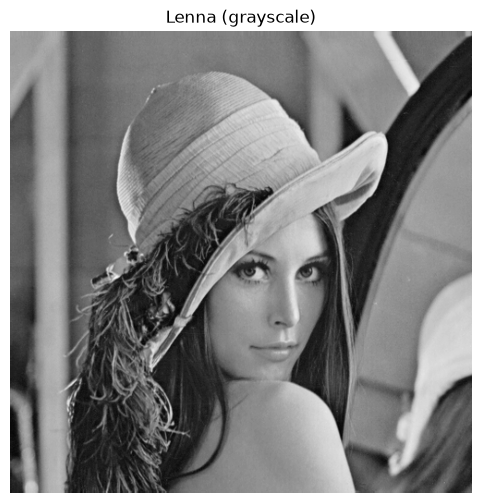

In [34]:
import cv2
import sys
import matplotlib.pyplot as plt

# ★ 오류 1: 파일명이 틀렸다. 실제 파일은 Lenna.jpeg 가 아니라 Lenna.png
#    imread는 파일을 못 읽어도 예외를 던지지 않고 조용히 None을 반환한다
#    → 그래서 다음 줄의 img.shape 에서 AttributeError 가 났던 것
img = cv2.imread("./data/fig/Lenna.png", cv2.IMREAD_GRAYSCALE)

# ★ 오류 2: None 검사는 img를 쓰기 "전에" 해야 의미가 있다 (원래는 주석 처리돼 있었음)
# ★ 오류 3: 노트북에서 sys.exit()은 SystemExit 트레이스백을 뿜는다 → 예외를 쓰는 게 깔끔
if img is None:
    raise FileNotFoundError("이미지를 읽지 못했습니다. 경로를 확인하세요: ./data/fig/Lenna.png")

print(type(img))   # <class 'numpy.ndarray'>  — OpenCV 이미지는 그냥 numpy 배열
print(img.shape)   # (500, 500)  — GRAYSCALE이라 채널 축이 없다! 컬러였다면 (500, 500, 3)
print(img.dtype)   # uint8 (0~255)

# ★ 오류 4: cv2.imshow는 별도 GUI 창을 띄우는데, macOS 주피터 커널에서는
#    Cocoa 이벤트 루프가 메인 스레드를 요구해서 커널이 멈추는 경우가 많다
#    → 노트북 안에서는 matplotlib으로 출력하는 것이 안전하다
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')   # 흑백은 cmap='gray' 필수 (안 주면 노랑/보라로 나옴)
plt.axis('off')
plt.title('Lenna (grayscale)')
plt.show()

width = 500, height = 500
resized: (250, 250, 3)


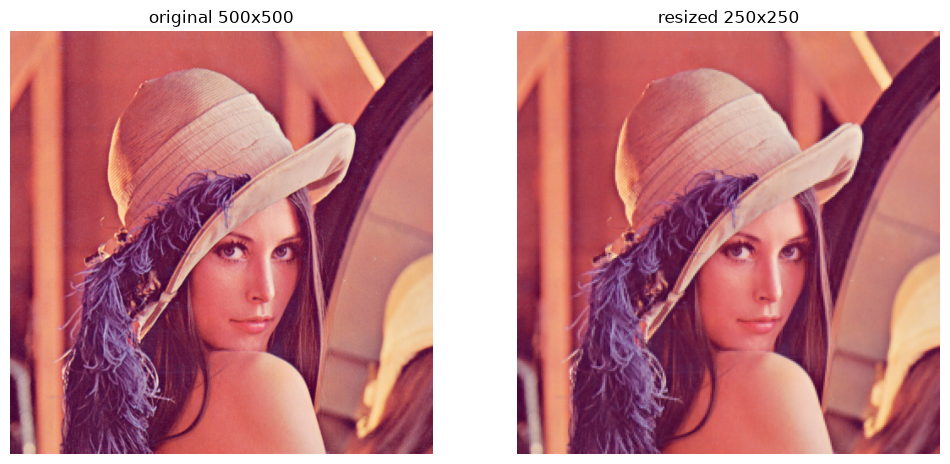

In [8]:
## cv2.namedWindow() — 노트북 안전 버전
import cv2
import sys
import matplotlib.pyplot as plt

# 실제 파일은 Lenna.bmp 가 아니라 Lenna.png
img = cv2.imread("./data/fig/Lenna.png", cv2.IMREAD_COLOR)

# ★ None 검사를 img.shape 보다 먼저! (원래 코드는 shape을 먼저 써서 터졌다)
if img is None:
    raise FileNotFoundError("이미지를 읽지 못했습니다. 경로를 확인하세요: ./data/fig/Lenna.png")

print("width = {}, height = {}".format(img.shape[1], img.shape[0]))  # shape은 (높이, 너비, 채널)

# ★ resize는 shape과 반대로 (너비, 높이) 순서로 넣는다 — 가장 헷갈리는 부분
img_resize = cv2.resize(img, (img.shape[1] // 2, img.shape[0] // 2))
print("resized:", img_resize.shape)

# 노트북에서는 matplotlib으로 확인 (imshow는 BGR→RGB 변환 필요)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'original {img.shape[1]}x{img.shape[0]}')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img_resize, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'resized {img_resize.shape[1]}x{img_resize.shape[0]}')
axes[1].axis('off')
plt.show()

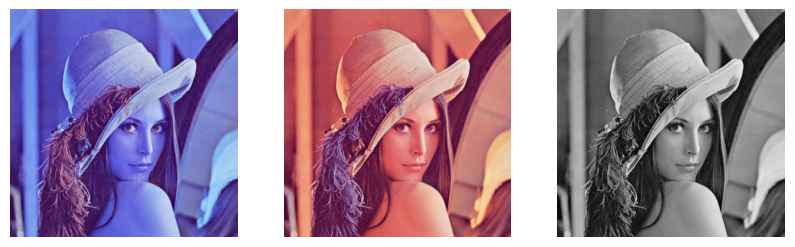

In [9]:
# matplotlib

import matplotlib.pyplot as plt
import cv2

img  = cv2.imread("./data/fig/Lenna.png", cv2.IMREAD_COLOR) # BGR
imgrgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #RGB
imggray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # GRAY

if img is None:
    print("Image read failed")
    sys.exit()

# cv2.namedWindow("dog", cv2.WINDOW_AUTOSIZE)
# cv2.imshow("dog", img)

# plt.imshow(imgrgb)
# plt.axis("off")
# plt.show()

plt.figure(figsize=(10,3))
plt.subplot(131), plt.imshow(img), plt.axis("off")
plt.subplot(132), plt.imshow(imgrgb), plt.axis("off")
plt.subplot(133), plt.imshow(imggray, cmap = "gray"), plt.axis("off")
plt.show()

# while True:
#     if cv2.waitKey() == 27:
#         break

# cv2.destroyAllWindows()

In [2]:
from urllib import request
import numpy as np
import cv2

In [3]:
# url = "https://upload.wikimedia.org/wikipedia/ko/thumb/2/24/Lenna.png/220px-Lenna.png"
url = "https://i.namu.wiki/i/1GQUprRurzHmmcilfqzztbmMzD1ZKrRFylL1AHAdIYlwAi1EV0vOKK8gsWO3SOilxt1Otiyt9pfSVe43qe4ObTqVqI-_ch0NlDM0MBlvc1r1s1ICDYoZKLtWZuZqh4PByQpQxOs9VCF1-5WW4EY55A.webp"

source = request.urlopen(url).read() # bytes
print(type(source))

<class 'bytes'>


In [4]:
image = np.array(bytearray(source), dtype = np.uint8)
print("image shape = ", image.shape) # (101968,)

# numpy 배열 형태의 byte 데이터로 이루어진 압축된 이미지를 디코딩하여 3채널 컬러(BRG) OpenCV 이미지 행렬로 변환하는 구문
# 주로 한글 파일 경로 문제 해결이나 메모리상의 바이너리 데이터를 다룰때 사용
image = cv2.imdecode(image, cv2.IMREAD_COLOR)
cv2.imwrite("Charistmas_download.png", image)

cv2.namedWindow("img", cv2.WINDOW_NORMAL)
cv2.imshow("img", image)

cv2.waitKey()
cv2.destroyAllWindows()

image shape =  (10140,)


In [5]:
# import glob
# img_files = glob.glob('./data/fig/images/*.jpg')

import os
img_list = os.listdir('./data/fig/images')
# print(img_list)

img_files = [] # list
for i in img_list:
    img_dir = './data/fig/images/' + i # python string
    img_files.append(img_dir)

# print(img_files)

cv2.namedWindow("folder images", cv2.WINDOW_NORMAL)
cv2.setWindowProperty("folder images", cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN)

idx = 0
while True:
# for i in img_files:

    img = cv2.imread(img_files[idx], cv2.IMREAD_COLOR)
    cv2.imshow('folder images', img)

    if cv2.waitKey(3000) == 27:
        break

    idx += 1

    if idx >= len(img_files):
        idx = 0

cv2.destroyAllWindows()

In [ ]:
img  = cv2.imread("./data/fig/Lenna.png", cv2.IMREAD_COLOR)

if img is None:
    print("image read failed")
    sys.exit()
print(img.shape)
print("img width = {}, height = {}".format(img.shape[1], img.shape[0]))

## 영상 픽셀값
x = 320
y = 240
print("x = {}, y = {} 의 픽셀값".format(x, y))
print(img[240, 320])
# print(img[200:300, 250:400])

# 실행했을 때 이미지 위에 그려지는 파란색 박스
img[50:300, 250:500] = (125, 44, 66) # BGR

cv2.namedWindow("image", cv2.WINDOW_AUTOSIZE)
cv2.imshow("image", img)

while True:
    if cv2.waitKey() == 27:
        break

cv2.destroyAllWindows()

(500, 500, 3)
img width = 500, height = 500
x = 320, y = 240 의 픽셀값
[172 185 242]


In [14]:
import numpy as np

# img1 = np.random.randint(0, 255, (200, 200), np.uint8) # int32
img2 = np.ones((1200, 800, 3), dtype = np.uint8)*255
# img3 = np.zeros((200, 200), np.uint8) + 255
# img4 = np.full((200, 200, 3), (255, 0, 255), np.uint8)

# cv2.imshow("rand int", img1)
cv2.imshow("rand ones", img2)
# cv2.imshow("rand zeros", img3)
# cv2.imshow("rand full", img4)


cv2.waitKey()
cv2.destroyAllWindows()

In [19]:
img = cv2.imread("./data/fig/Lenna.png", cv2.IMREAD_COLOR)

if img is None:
    print("image read failed")
    sys.exit()

# img2 = img
# deep copy
img2 = img.copy()

img2[100:150, 200:300] = (255, 0, 0)

cv2.namedWindow("rose", cv2.WINDOW_AUTOSIZE)
cv2.imshow("rose", img)
cv2.imshow("rose copy", img2)


while True:
    if cv2.waitKey() == ord("q"):
        break

cv2.destroyAllWindows()

In [26]:
## 부분영상: 영상 합성에 유리

# 1. 이미지 로드
img = cv2.imread("./data/fig/Lenna.png", cv2.IMREAD_COLOR)

if img is None:
    print("image read failed")
    sys.exit()

lena_eye = img[240:290, 250:300]

# 2. 레나의 오른쪽 눈(화면상 왼쪽 눈) 영역 슬라이싱 (y축 범위, x축 범위)
# circle(img, center, radius, color[, thickness[, lineType[, shift]]]) -> img
# (267 - 250, 265 - 240) -> (17, 25) 위치에 반지름 15의 원을 그립니다.
cv2.circle(lena_eye, (17, 25), 15, (0, 0, 255), 2)
print(lena_eye.shape)

cv2.namedWindow("lena", cv2.WINDOW_NORMAL)
cv2.imshow("lena", img)
cv2.imshow("lena eye", lena_eye)

while True:
    if cv2.waitKey() == 27: # ESC 키 입력 시 종료
        break

cv2.destroyAllWindows()

(50, 50, 3)


In [28]:
import cv2

## copyTo(): 영상합성
src = cv2.imread("./data/fig/airplane.png", cv2.IMREAD_COLOR)
mask = cv2.imread("./data/fig/mask_plane.png", cv2.IMREAD_GRAYSCALE)
dst = cv2.imread("./data/fig/field.png", cv2.IMREAD_COLOR) 

print(dst.shape)

if src is None or mask is None or dst is None:
    print("Images read failed")
    sys.exit()

# src와 mask는 반드시 같은 크기여야 합니다.
# dst는 src보다 커도 됩니다.   
# mask은  흰색(255)과 검은색(0)으로 되어 있어야만 합니다.
print("src :", src.shape)
print("mask:", mask.shape)
print("dst :", dst.shape)

print("mask min:", mask.min())
print("mask max:", mask.max())

_, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
print("mask unique:", np.unique(mask))
## numpy class
# dst[mask > 0] = src[mask > 0]
cv2.copyTo(src, mask, dst)

cv2.imshow("src", src)
cv2.imshow("mask",mask)
cv2.imshow("dst",dst)

cv2.waitKey()
cv2.destroyAllWindows()

(144, 213, 3)
src : (144, 213, 3)
mask: (144, 213)
dst : (144, 213, 3)
mask min: 0
mask max: 255
mask unique: [  0 255]


In [32]:
import cv2
import numpy as np

img = np.full((250, 250, 3), 255, dtype=np.uint8)

cv2.line(img, (50, 10), (200, 10), (255, 0, 0), 1)
cv2.line(img, (50, 60), (200, 60), (0, 255, 0), 2)
cv2.line(img, (50, 110), (200, 110), (0, 0, 255), 3)
cv2.line(img, (50, 160), (200, 160), (0, 0, 0), 4)
cv2.line(img, (50, 210), (200, 210), (255, 0, 255), 5)

cv2.imshow('Lines', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [34]:
import cv2
import numpy as np

img = np.full((250, 250, 3), 255, dtype=np.uint8)

cv2.rectangle(img, (50, 10), (200, 50), (255, 0, 0))
cv2.rectangle(img, (50, 60), (200, 100), (255, 0, 0), 5)
cv2.rectangle(img, (50, 110), (200, 150), (255, 0, 0), -1)
cv2.rectangle(img, (50, 160), (200, 200), (255, 0, 0), -1)
cv2.rectangle(img, (50, 160), (200, 200), (0, 0, 255), 5)

cv2.imshow('Rectangle', img)
# cv2.waitKey(0)
while True:
    if cv2.waitKey() == 27: # ESC 키 입력 시 종료
        break
cv2.destroyAllWindows()

In [40]:
import cv2
import numpy as np

img = np.full((250, 250, 3), 255, dtype=np.uint8)

cv2.circle(img, (50, 50), 50, (255, 0, 0))
cv2.circle(img, (100, 100), 50, (0, 255, 0), -1)
cv2.circle(img, (100, 100), 100, (0, 0, 255), 5)
cv2.circle(img, (200, 200), 50, (0, 0, 0), 50)

cv2.imshow('Circle', img)
# cv2.waitKey(0)
while True:
    if cv2.waitKey() == 27: # ESC 키 입력 시 종료
        break
cv2.destroyAllWindows()

In [46]:
import cv2
import numpy as np

img = np.full((250, 250, 3), 255, dtype=np.uint8)

cv2.ellipse(img, (60,60), (50,30), -30, 0, 360, (255,0,0), 2)
cv2.ellipse(img, (160,60), (50,30), 0, 0, 360, (0,0,255), -1)
cv2.ellipse(img, (60,160), (50,30), 30, 0, 180, (255,0,0), 2)
cv2.ellipse(img, (160,160), (50,30), 90, 0, 180, (0,0,255), -1)
cv2.ellipse(img, (160,160), (50,30), 90, 180, 360, (255,0,0), -1)

cv2.imshow('Ellipse',img)
# cv2.waitKey(0)
while True:
    if cv2.waitKey() == 27: # ESC 키 입력 시 종료
        break
cv2.destroyAllWindows()

In [ ]:
import cv2
import numpy as np

img = np.full((250, 250, 3), 255, dtype=np.uint8)
points = np.array([[[60,60], [100,10], [200,60], [150,100],
                    [100, 100]]], dtype=np.int32)

cv2.polylines(img, points, True, (255, 0, 0), 5)
cv2.polylines(img, points+[0,100], False, (0, 0, 255), 10)

cv2.imshow('Polylines',img)
# cv2.waitKey(0)
while True:
    if cv2.waitKey() == 27: # ESC 키 입력 시 종료
        break
    
cv2.destroyAllWindows()

In [ ]:
import cv2
import numpy as np

img = np.full((250, 250, 3), 255, dtype=np.uint8)

cv2.putText(img, "Hello Python", (10,50), cv2.FONT_ITALIC, 1, (255,0,0)) # 배열이 아닌 좌표
cv2.putText(img, "Hello Python", (10,80), cv2.FONT_ITALIC, 0.5, (0,0,255))
cv2.putText(img, "Hello Python", (10,150), cv2.FONT_HERSHEY_DUPLEX, 2, (0,0,0))
cv2.putText(img, "Hello Python", (10,200), cv2.FONT_HERSHEY_TRIPLEX, 1, (0,0,0))

cv2.imshow('Text',img)
# cv2.waitKey(0)
while True:
    if cv2.waitKey() == 27: # ESC 키 입력 시 종료
        break
    
cv2.destroyAllWindows()

In [67]:
import platform

# OS에 따른 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')    # 맥: 애플 고딕
else:
    plt.rc('font', family='NanumBarunGothic') # 리눅스

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

shape=(300, 400, 3), dtype=uint8
[0,0] BGR: [220 220 220]


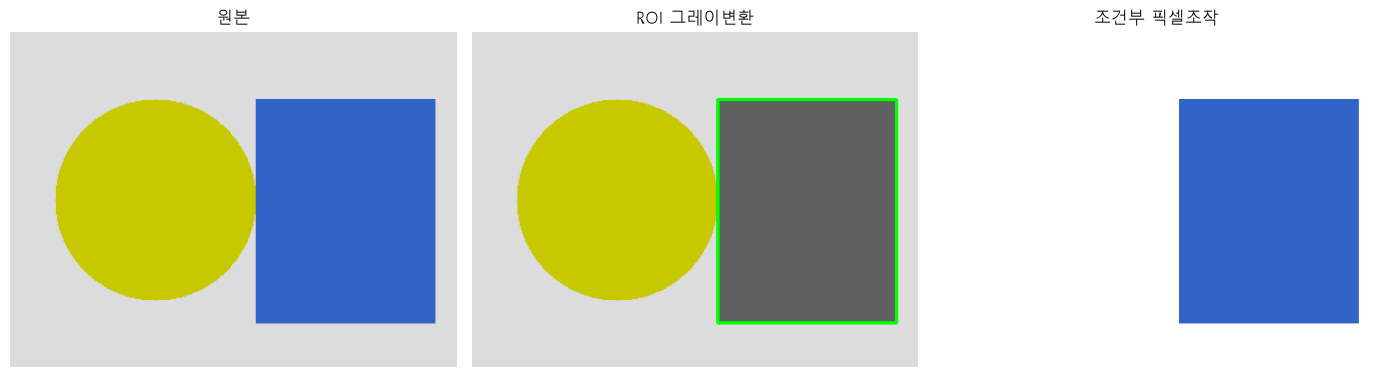

ROI 완료!


In [ ]:
""" 픽셀 접근·ROI 선택·조작"""
import cv2  # 이미지 처리를 위한 OpenCV 라이브러리 불러오기
import numpy as np  # 행렬 연산 및 배열 생성을 위한 NumPy 불러오기
import matplotlib.pyplot as plt  # 시각화를 위한 Matplotlib 불러오기

# 1. 원본 이미지 생성 (세로 300, 가로 400, 3채널 BGR, uint8 타입)
img = np.zeros((300, 400, 3), dtype=np.uint8)
img[:] = (220, 220, 220)  # 배경을 연한 회색(220, 220, 220)으로 채우기

# 이미지에 도형 추가 (원, 사각형)
cv2.circle(img, (130, 150), 90, (0, 200, 200), -1)  # 노란색 원 (중심: 130,150 / 반지름: 90)
cv2.rectangle(img, (220, 60), (380, 260), (200, 100, 50), -1)  # 파란계열 사각형 (좌상단: 220,60 / 우하단: 380,260)

# 이미지의 기본 정보(크기/채널, 데이터 타입, 특정 위치 픽셀값) 출력
print(f"shape={img.shape}, dtype={img.dtype}")
print(f"[0,0] BGR: {img[0,0]}")  # (0,0) 좌표의 BGR 픽셀값 출력



# 2. ROI(관심 영역) 지정 및 조작
# 사각형 영역(y: 60~260, x: 220~380)을 복사해서 ROI로 추출
roi = img[60:260, 220:380].copy()

# 추출한 ROI를 그레이스케일(1채널)로 변환
roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

# 원본(3채널)에 다시 합성하기 위해 그레이스케일 이미지를 3채널 BGR로 재변환
roi_gray_bgr = cv2.cvtColor(roi_gray, cv2.COLOR_GRAY2BGR)

# 원본을 복사한 뒤, 해당 사각형 위치에 흑백 변환된 ROI를 덮어쓰기 (합성)
result = img.copy()
result[60:260, 220:380] = roi_gray_bgr

# 처리된 ROI 영역의 테두리를 초록색 선(두께 2)으로 표시
cv2.rectangle(result, (220, 60), (380, 260), (0, 255, 0), 2)



# 3. 조건부 픽셀 마스킹
img_th = img.copy()  # 원본 이미지 복사
gray_t = cv2.cvtColor(img_th, cv2.COLOR_BGR2GRAY)  # 조건판단을 위해 그레이스케일로 변환

# 밝기(그레이스케일 값)가 128 이상인 모든 픽셀을 흰색[255, 255, 255]으로 일괄 변경
img_th[gray_t >= 128] = [255, 255, 255]



# 4. 결과 시각화 및 저장
# 1행 3열 크기(14x5 인치)의 그래프 서브플롯 생성
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# 원본, ROI 변환 결과, 조건부 조작 결과를 반복문으로 순회하며 출력
for ax, im, t in zip(axes, [img, result, img_th], ["원본", "ROI 그레이변환", "조건부 픽셀조작"]):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))  # Matplotlib에 맞게 BGR -> RGB 변환
    ax.set_title(t)  # 각 서브플롯의 제목 설정
    ax.axis("off")  # 눈금 및 좌표축 숨기기

plt.tight_layout()  # 플롯 간 여백 자동 정돈
plt.savefig("roi_demo.png", dpi=100, bbox_inches="tight")  # 이미지 파일 저장 (100 DPI)
plt.show()  # 완성된 결과창 표시

print("ROI 완료!")

cv2.imshow('BASIC', img)
cv2.imshow('ROI', result)
cv2.imshow('FILTER', img_th)

while True:
    if cv2.waitKey() == 27:
        break

cv2.destroyAllWindows()

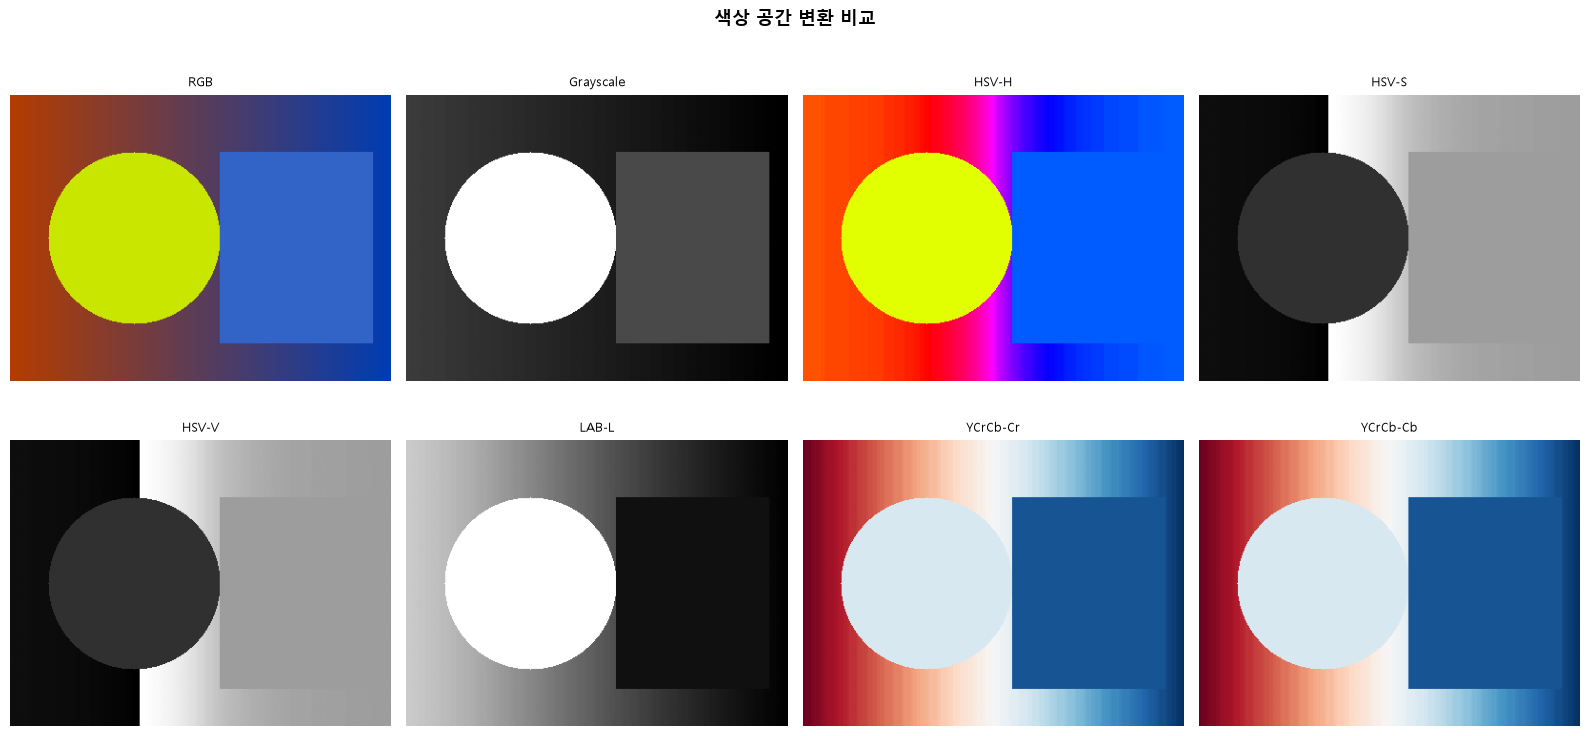

색상 공간 변환 완료!


KeyboardInterrupt: 

In [73]:
"""색상 공간 변환"""
import cv2  # 이미지 처리를 위한 OpenCV 라이브러리 불러오기
import numpy as np  # 행렬 연산 및 배열 생성을 위한 NumPy 불러오기
import matplotlib.pyplot as plt  # 시각화를 위한 Matplotlib 불러오기

# 1. 테스트용 샘플 이미지 직접 생성 (세로 300, 가로 400, 3채널 BGR, uint8)
img = np.zeros((300, 400, 3), dtype=np.uint8)

# 가로 방향으로 픽셀을 이동하며 BGR 색상 그라데이션 적용
for x in range(400): 
    img[:, x] = [int(x / 400 * 180), 60, int((1 - x / 400) * 180)]

# 샘플 이미지에 민트색 원과 주황/파란 계열 사각형 그리기
cv2.circle(img, (130, 150), 90, (0, 230, 200), -1)  # 원 (중심: 130,150 / 반지름: 90)
cv2.imshow('circle', img)
cv2.rectangle(img, (220, 60), (380, 260), (200, 100, 50), -1)  # 사각형 (좌상단: 220,60 / 우하단: 380,260)
cv2.imshow('rectangle', img)

# 2. 색상 공간 변환 설정 리스트 (OpenCV 변환 코드, 타이틀 이름, Matplotlib 컬러맵)
conversions = [
    (cv2.COLOR_BGR2RGB,   "RGB",      None),     # BGR을 RGB로 변환 (기본 컬러)
    (cv2.COLOR_BGR2GRAY,  "Grayscale","gray"),   # 그레이스케일 변환 (단일 채널)
    (cv2.COLOR_BGR2HSV,   "HSV-H",    "hsv"),    # HSV 변환 후 H(Hue: 색상) 채널 추출
    (cv2.COLOR_BGR2HSV,   "HSV-S",    "gray"),   # HSV 변환 후 S(Saturation: 채도) 채널 추출
    (cv2.COLOR_BGR2HSV,   "HSV-V",    "gray"),   # HSV 변환 후 V(Value: 명도) 채널 추출
    (cv2.COLOR_BGR2LAB,   "LAB-L",    "gray"),   # LAB 변환 후 L(Lightness: 밝기) 채널 추출
    (cv2.COLOR_BGR2YCrCb, "YCrCb-Cr", "RdBu_r"), # YCrCb 변환 후 Cr(Red-Difference: 赤 색상차) 채널 추출
    (cv2.COLOR_BGR2YCrCb, "YCrCb-Cb", "RdBu_r"), # YCrCb 변환 후 Cb(Blue-Difference: 靑 색상차) 채널 추출
]

# 3. Matplotlib 서브플롯 생성 (2행 4열 그리드, 전체 크기 16x8 인치)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("색상 공간 변환 비교", fontsize=13, fontweight="bold")  # 전체 상단 제목 설정

# 2행 4열의 서브플롯(axes.flat)과 변환 설정을 1:1로 매핑하여 루프 실행
for ax, (code, title, cmap) in zip(axes.flat, conversions):
    converted = cv2.cvtColor(img, code)  # 설정된 코드에 맞춰 색상 공간 변환 수행
    
    # 타이틀 이름에 따라 추출할 특정 채널(1D/2D Slice) 결정
    if "H" in title: 
        disp = converted[:, :, 0]  # HSV의 0번째 채널 (Hue: 색조)
    elif "S" in title: 
        disp = converted[:, :, 1]  # HSV의 1번째 채널 (Saturation: 채도)
    elif "V" in title or "L" in title: 
        disp = converted[:, :, 2] if "L" in title else converted[:, :, 2]  # V(2번) 또는 LAB-L 채널 추출
    elif "Cr" in title: 
        disp = converted[:, :, 1]  # YCrCb의 1번째 채널 (Cr)
    elif "Cb" in title: 
        disp = converted[:, :, 2]  # YCrCb의 2번째 채널 (Cb)
    elif "Grayscale" in title: 
        disp = converted  # 흑백 이미지 전체 (2차원 배열)
    else: 
        disp = converted  # RGB 이미지 전체 (3차원 배열)
        
    ax.imshow(disp, cmap=cmap)  # 지정된 컬러맵(cmap)으로 이미지 출력
    ax.set_title(title, fontsize=9)  # 서브플롯 제목 지정
    ax.axis("off")  # 눈금 및 축 숨기기

# 4. 레이아웃 정돈 및 이미지 파일 저장/출력
plt.tight_layout()  # 플롯 간 여백 자동 조절
plt.savefig("colorspace_demo.png", dpi=100, bbox_inches="tight")  # 결과 이미지 저장 (100 DPI)
plt.show()  # 화면에 결과 표시

print("색상 공간 변환 완료!")

while True:
    if cv2.waitKey() == 27:
        break

cv2.destroyAllWindows()

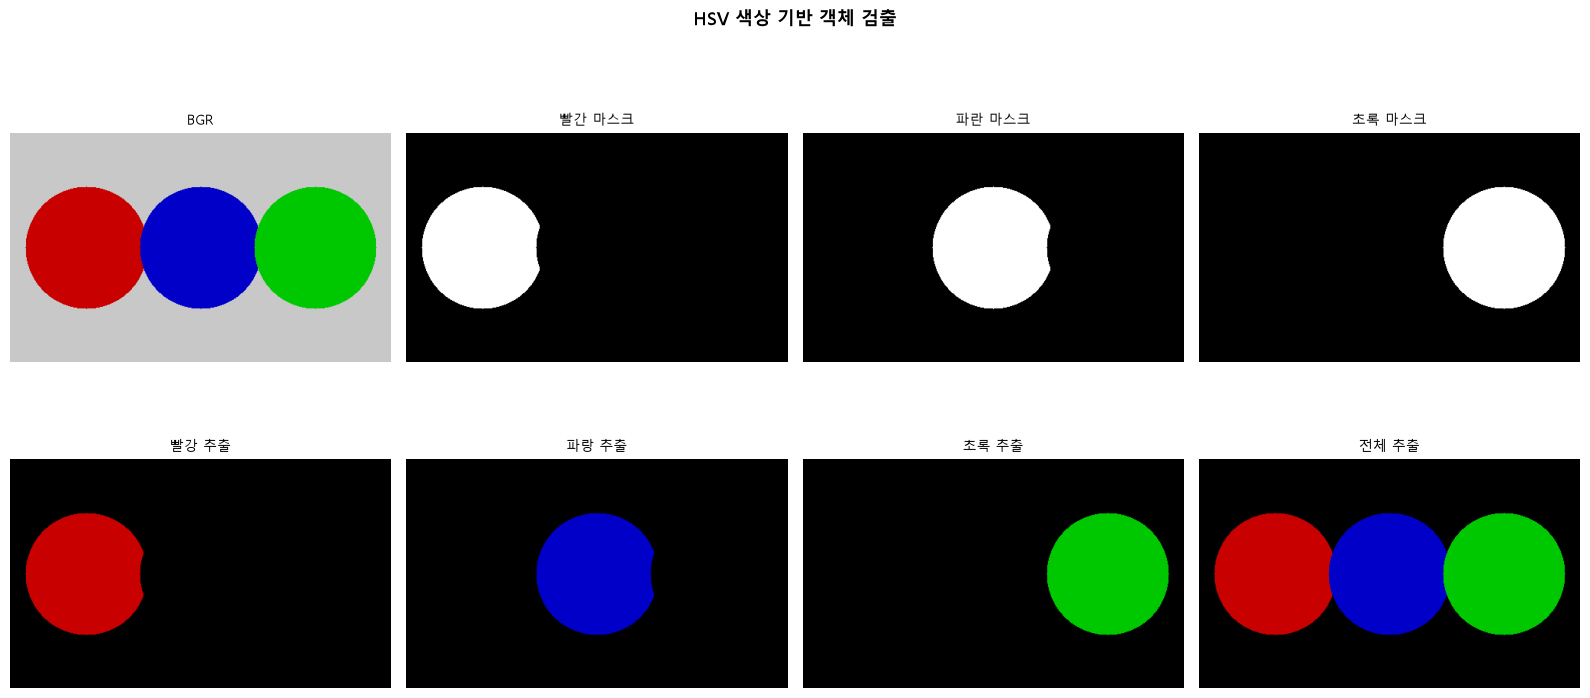

HSV 마스킹 완료!


In [74]:
""" HSV 색상 마스킹으로 객체 검출"""
import cv2  # 이미지 처리를 위한 OpenCV 라이브러리 불러오기
import numpy as np  # 행렬 연산 및 배열 생성을 위한 NumPy 불러오기
import matplotlib.pyplot as plt  # 시각화를 위한 Matplotlib 불러오기

# 1. 테스트용 샘플 이미지 생성 (세로 300, 가로 500, 3채널 BGR, uint8)
img = np.zeros((300, 500, 3), dtype=np.uint8)
img[:] = (200, 200, 200)  # 배경을 연한 회색(200, 200, 200)으로 채우기

# 빨간색, 파란색, 초록색 원 그리기 (BGR 순서 주의)
cv2.circle(img, (100, 150), 80, (0, 0, 200), -1)   # BGR 기준 빨간색 원 (중심: 100, 150)
cv2.circle(img, (250, 150), 80, (200, 0, 0), -1)   # BGR 기준 파란색 원 (중심: 250, 150)
cv2.circle(img, (400, 150), 80, (0, 200, 0), -1)   # BGR 기준 초록색 원 (중심: 400, 150)

# BGR 이미지를 HSV 색상 공간으로 변환 (H: 0~180, S: 0~255, V: 0~255)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# 2. 색상별 HSV 범위를 지정하여 마스크(Mask) 생성
# 빨간색은 Hue 양끝 범위를 모두 포함해야 함 (0~10 및 170~180 범위)
mask_r1 = cv2.inRange(hsv, np.array([0, 100, 100]), np.array([10, 255, 255]))      # 빨강 하단 범위 마스크
mask_r2 = cv2.inRange(hsv, np.array([170, 100, 100]), np.array([180, 255, 255]))  # 빨강 상단 범위 마스크
mask_red = cv2.bitwise_or(mask_r1, mask_r2)  # 비트 OR 연산으로 두 빨간색 영역을 하나로 합침

# 파란색 마스크 생성 (Hue: 100~130 범위)
mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([130, 255, 255]))

# 초록색 마스크 생성 (Hue: 40~80 범위)
mask_green = cv2.inRange(hsv, np.array([40, 100, 100]), np.array([80, 255, 255]))

# 3. 시각화할 항목 리스트 정의 (이미지/마스크 데이터, 제목, 컬러맵 옵션)
items = [
    (img, "BGR", None),  # 원본 이미지
    (mask_red, "빨간 마스크", "gray"),    # 빨간색 흑백 마스크
    (mask_blue, "파란 마스크", "gray"),   # 파란색 흑백 마스크
    (mask_green, "초록 마스크", "gray"),  # 초록색 흑백 마스크
    (cv2.bitwise_and(img, img, mask=mask_red), "빨강 추출", None),    # 마스크를 이용한 빨간 객체만 추출
    (cv2.bitwise_and(img, img, mask=mask_blue), "파랑 추출", None),   # 마스크를 이용한 파란 객체만 추출
    (cv2.bitwise_and(img, img, mask=mask_green), "초록 추출", None),  # 마스크를 이용한 초록 객체만 추출
    # 모든 마스크(빨강, 파랑, 초록)를 비트 OR 연산으로 합친 후 모든 객체 한 번에 추출
    (cv2.bitwise_and(img, img, mask=cv2.bitwise_or(mask_red, cv2.bitwise_or(mask_blue, mask_green))), "전체 추출", None)
]

# 4. Matplotlib 서브플롯 생성 (2행 4열 그리드, 전체 크기 16x8 인치)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("HSV 색상 기반 객체 검출", fontsize=13, fontweight="bold")  # 상단 제목 설정

# 2행 4열의 각 좌표축(axes.flat)에 순서대로 이미지를 매핑하여 시각화
for ax, (im, t, cmap) in zip(axes.flat, items):
    # 컬러맵이 없는 경우(컬러 이미지) Matplotlib에 맞게 BGR -> RGB 변환 수행
    disp = cv2.cvtColor(im, cv2.COLOR_BGR2RGB) if cmap is None else im
    ax.imshow(disp, cmap=cmap)  # 이미지 출력
    ax.set_title(t, fontsize=10)  # 서브플롯 제목 설정
    ax.axis("off")  # 축 눈금 숨기기

# 5. 레이아웃 정돈 및 이미지 저장/출력
plt.tight_layout()  # 플롯 간 여백 자동 조절
plt.savefig("hsv_masking.png", dpi=100, bbox_inches="tight")  # 결과 그래프를 파일로 저장
plt.show()  # 화면에 결과 창 출력

print("HSV 마스킹 완료!")

img.shape : (400, 600, 3)


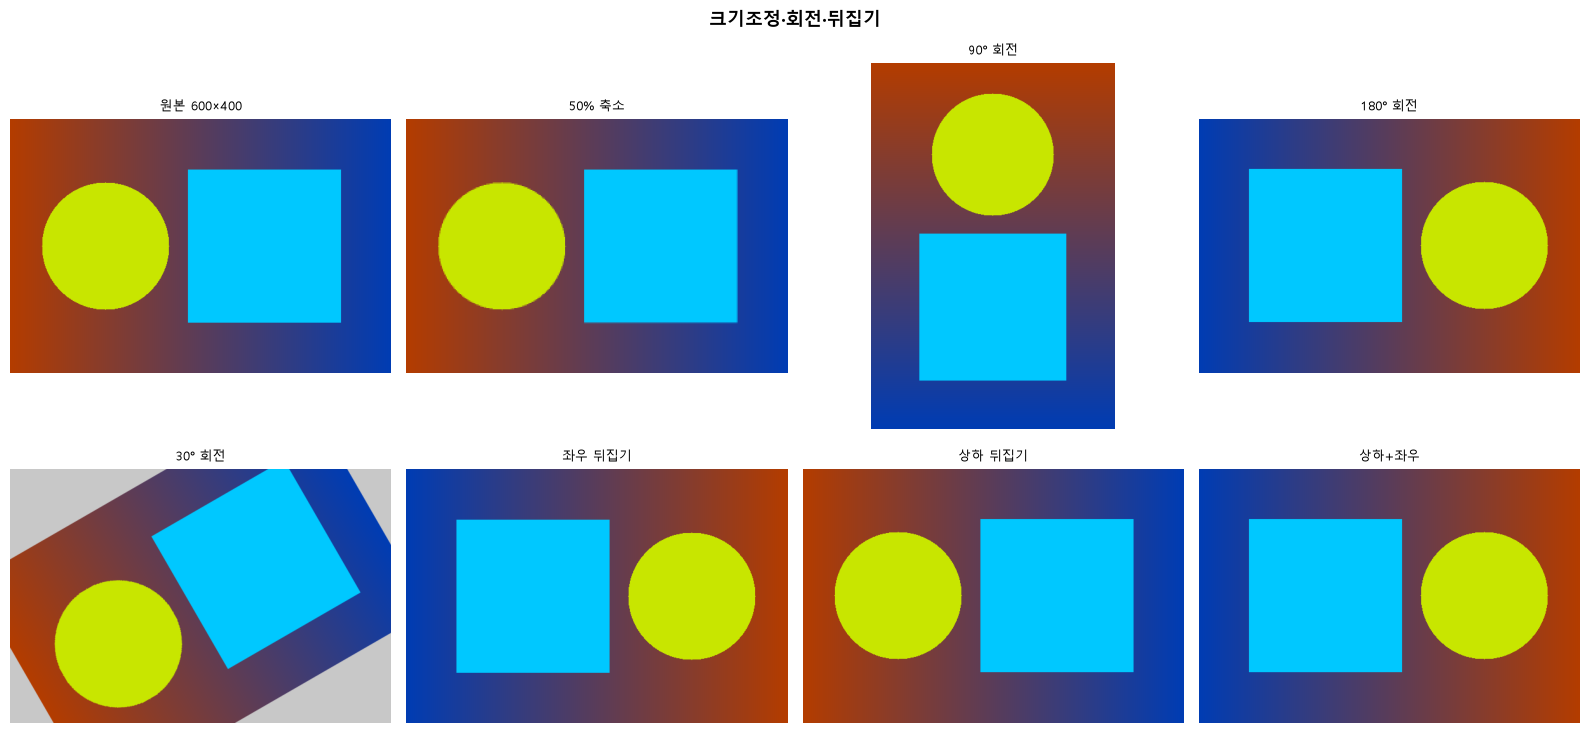

✅ 변환 완료!


In [92]:
""" 크기 조정·회전·뒤집기"""
import cv2  # 이미지 처리를 위한 OpenCV 라이브러리 불러오기
import numpy as np  # 행렬 연산 및 배열 생성을 위한 NumPy 불러오기
import matplotlib.pyplot as plt  # 시각화를 위한 Matplotlib 불러오기

# 1. 테스트용 샘플 이미지를 생성하는 함수 정의
def make_img():
    # 세로 400, 가로 600, 3채널(BGR) 크기의 검은색 도화지 생성
    img = np.zeros((400, 600, 3), dtype=np.uint8)
    
    # 가로 방향으로 픽셀을 이동하며 BGR 그라데이션 적용
    for x in range(600): 
        img[:, x] = [int(x / 600 * 180), 60, int((1 - x / 600) * 180)]
        
    # 샘플 이미지 위에 민트색 원과 하늘색 사각형 그리기
    cv2.circle(img, (150, 200), 100, (0, 230, 200), -1)       # 원 (중심: 150,200 / 반지름: 100)
    cv2.rectangle(img, (280, 80), (520, 320), (255, 200, 0), -1) # 사각형 (좌상단: 280,80 / 우하단: 520,320)
    return img

# 2. 이미지 생성 및 기본 기하학적 변환 연산 수행
img = make_img()  # 이미지 생성
print(f'img.shape : {img.shape}')
h, w = img.shape[:2]  # 이미지의 높이(h)와 너비(w) 추출

# 크기 축소: 가로/세로 비율을 각각 0.5배(50%)로 축소, 축소에 최적화된 INTER_AREA 보간법 적용
img_half = cv2.resize(img, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)

# 임의 각도 회전: 이미지 중심점을 기준(w//2, h//2)으로 반시계방향 30도 회전 행렬(M) 생성 (배율 1.0)
M = cv2.getRotationMatrix2D((w // 2, h // 2), 30, 1.0)

# 2D 어파인 변환을 적용하여 30도 회전, 회전 후 비어있는 여백은 밝은 회색(200, 200, 200)으로 채움
img_rot = cv2.warpAffine(img, M, (w, h), borderValue=(200, 200, 200))
cv2.imshow('img_rot', img_rot)

# 이미지 대칭 반전 (Flip)
img_fh = cv2.flip(img, 1)   # 1: 좌우 대칭 (좌우 뒤집기)
cv2.imshow('img_fh', img_fh)

img_fv = cv2.flip(img, 0)   # 0: 상하 대칭 (상하 뒤집기)
cv2.imshow('img_fv', img_fv)

# 3. 시각화할 결과물 배열 정의 (변환된 이미지, 출력할 제목)
items = [
    (img, f"원본 {w}×{h}"),                                      # 원본 이미지
    (img_half, "50% 축소"),                                        # 50% 축소 이미지
    (cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE), "90° 회전"),        # 시계 방향 90도 고속 회전
    (cv2.rotate(img, cv2.ROTATE_180), "180° 회전"),                # 180도 고속 회전
    (img_rot, "30° 회전"),                                         # 어파인 변환을 이용한 30도 커스텀 회전
    (img_fh, "좌우 뒤집기"),                                       # 좌우 반전
    (img_fv, "상하 뒤집기"),                                       # 상하 반전
    (cv2.flip(img, -1), "상하+좌우")                               # -1: 상하 및 좌우 동시 대칭 (대각선 반전)
]

# 4. Matplotlib 서브플롯 생성 (2행 4열 그리드, 전체 크기 16x8 인치)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("크기조정·회전·뒤집기", fontsize=13, fontweight="bold")  # 상단 전체 제목 설정

# 2행 4열의 각 축(axes.flat)에 순서대로 이미지를 매핑하여 시각화
for ax, (im, t) in zip(axes.flat, items):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))  # Matplotlib에 맞게 BGR -> RGB 변환 후 표시
    ax.set_title(t, fontsize=9)                     # 서브플롯 제목 지정
    ax.axis("off")                                  # 눈금 및 축 숨기기

# 5. 레이아웃 정돈 및 이미지 저장/출력
plt.tight_layout()  # 서브플롯 간 여백 자동 조절
plt.savefig("transform_demo.png", dpi=100, bbox_inches="tight")  # 결과 이미지를 파일로 저장
plt.show()  # 화면에 결과창 출력

print("✅ 변환 완료!")

while True:
    if cv2.waitKey() == 27:
        break

cv2.destroyAllWindows()

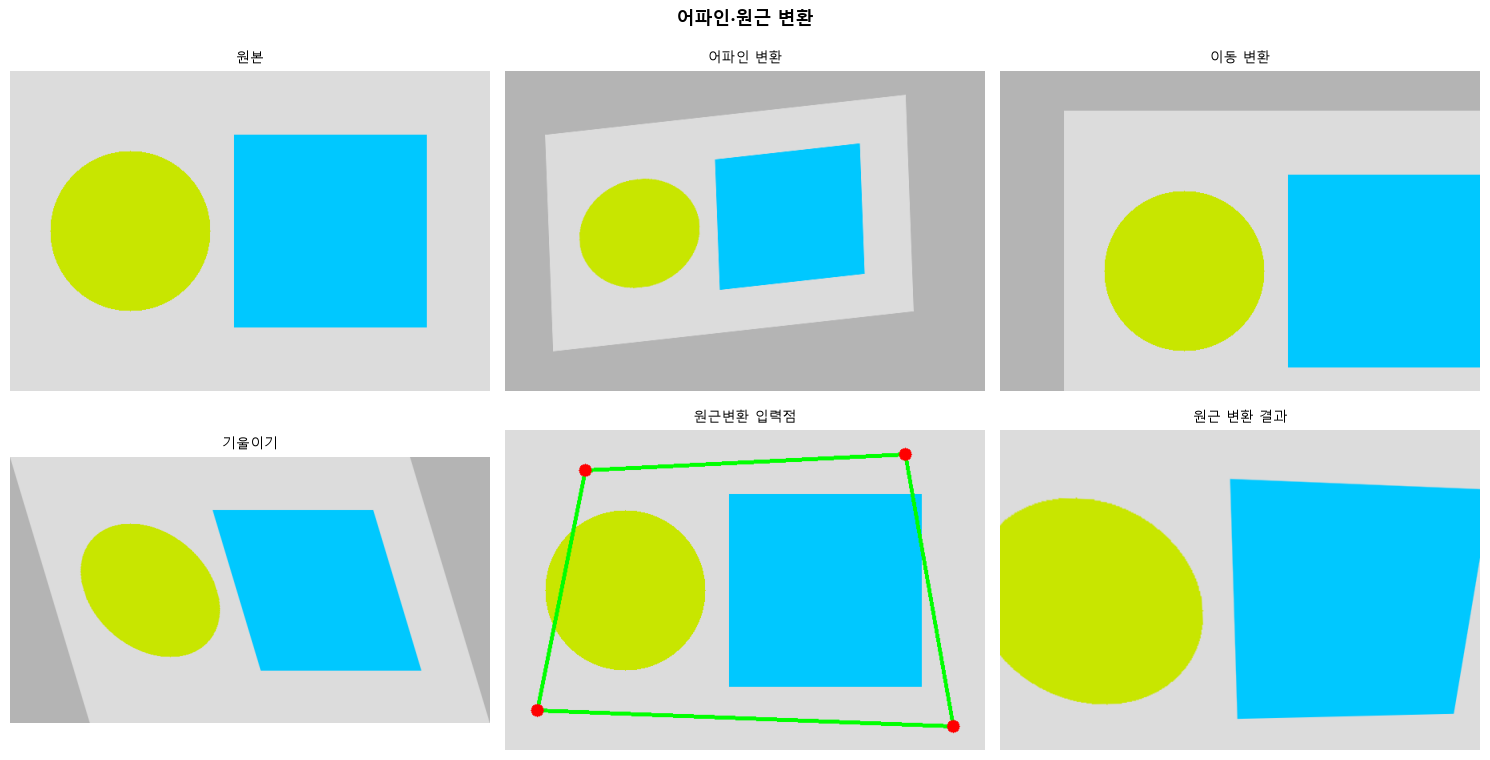

✅ 어파인·원근 완료!


In [ ]:
"""어파인·원근 변환"""
import cv2  # 이미지 처리를 위한 OpenCV 라이브러리 불러오기
import numpy as np  # 행렬 연산 및 배열 생성을 위한 NumPy 불러오기
import matplotlib.pyplot as plt  # 시각화를 위한 Matplotlib 불러오기

# 1. 테스트용 샘플 이미지를 생성하는 함수 정의
def make_img():
    # 세로 400, 가로 600, 3채널(BGR) 크기의 배경 생성
    img = np.zeros((400, 600, 3), dtype=np.uint8)
    img[:] = (220, 220, 220)  # 배경을 연한 회색(220, 220, 220)으로 채우기
    
    # 샘플 이미지 위에 민트색 원과 하늘색 사각형 그리기
    cv2.circle(img, (150, 200), 100, (0, 230, 200), -1)       # 원 (중심: 150,200 / 반지름: 100)
    cv2.rectangle(img, (280, 80), (520, 320), (255, 200, 0), -1) # 사각형 (좌상단: 280,80 / 우하단: 380,260)
    return img

# 2. 이미지 생성 및 어파인(Affine) 변환 연산
img = make_img()  # 이미지 생성
h, w = img.shape[:2]  # 높이(h)와 너비(w) 추출

# 어파인 변환을 위한 원본 점 3개(src)와 이동할 목표 점 3개(dst) 정의
src = np.float32([[0, 0], [w - 1, 0], [0, h - 1]])
dst = np.float32([[50, 80], [w - 100, 30], [60, h - 50]])
# 3점 대응 관계로부터 2x3 어파인 행렬을 생성하고 변환 적용 (여백은 회색으로 채움)
img_affine = cv2.warpAffine(img, cv2.getAffineTransform(src, dst), (w, h), borderValue=(180, 180, 180))

# 이동 변환(Translation): x축으로 +80, y축으로 +50 평행 이동 행렬 적용
tx, ty = 80, 50
img_shift = cv2.warpAffine(img, np.float32([[1, 0, tx], [0, 1, ty]]), (w, h), borderValue=(180, 180, 180))

# 3. 원근(Perspective) 변환 연산
# 원근 변환을 위한 원본 외곽 사각형 점 4개(src_q)와 펼쳐서 맞출 목표 점 4개(dst_q) 정의
src_q = np.float32([[100, 50], [500, 30], [560, 370], [40, 350]])
dst_q = np.float32([[0, 0], [w - 1, 0], [w - 1, h - 1], [0, h - 1]])

# 4점 대응 관계로부터 3x3 원근 변환 행렬을 구하고 2D 투영 변환 적용
img_persp = cv2.warpPerspective(img, cv2.getPerspectiveTransform(src_q, dst_q), (w, h))

# 원근 변환 전, 입력점 4개와 제어 영역을 표시할 시각화용 이미지 작성
img_marked = img.copy()
cv2.polylines(img_marked, [src_q.astype(np.int32).reshape(-1, 1, 2)], True, (0, 255, 0), 3)  # 영역 테두리(초록선)
for pt in src_q: 
    cv2.circle(img_marked, tuple(pt.astype(int)), 8, (0, 0, 255), -1)  # 모서리 매핑 점(빨간 원)

# 4. 시각화할 결과물 배열 정의 (변환 데이터, 제목)
items = [
    (img, "원본"),
    (img_affine, "어파인 변환"),
    (img_shift, "이동 변환"),
    # 기울이기(Shear): x축 방향으로 0.3 비율만큼 찌그러뜨림 (너비 공간 확장)
    (cv2.warpAffine(img, np.float32([[1, 0.3, 0], [0, 1, 0]]), (int(w + h * 0.3), h), borderValue=(180, 180, 180)), "기울이기"),
    (img_marked, "원근변환 입력점"),
    (img_persp, "원근 변환 결과")
]

# 5. Matplotlib 서브플롯 생성 (2행 3열 그리드, 전체 크기 15x8 인치)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("어파인·원근 변환", fontsize=13, fontweight="bold")  # 상단 전체 제목 설정

# 2행 3열의 각 좌표축(axes.flat)에 순서대로 이미지를 매핑하여 시각화
for ax, (im, t) in zip(axes.flat, items):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))  # Matplotlib에 맞게 BGR -> RGB 변환 후 표시
    ax.set_title(t, fontsize=10)                    # 서브플롯 제목 설정
    ax.axis("off")                                 # 축 눈금 숨기기

# 6. 레이아웃 정돈 및 이미지 저장/출력
plt.tight_layout()  # 플롯 간 여백 자동 조절
plt.savefig("affine_perspective.png", dpi=100, bbox_inches="tight")  # 결과 그래프를 파일로 저장
plt.show()  # 화면에 결과 창 출력

print("✅ 어파인·원근 완료!")

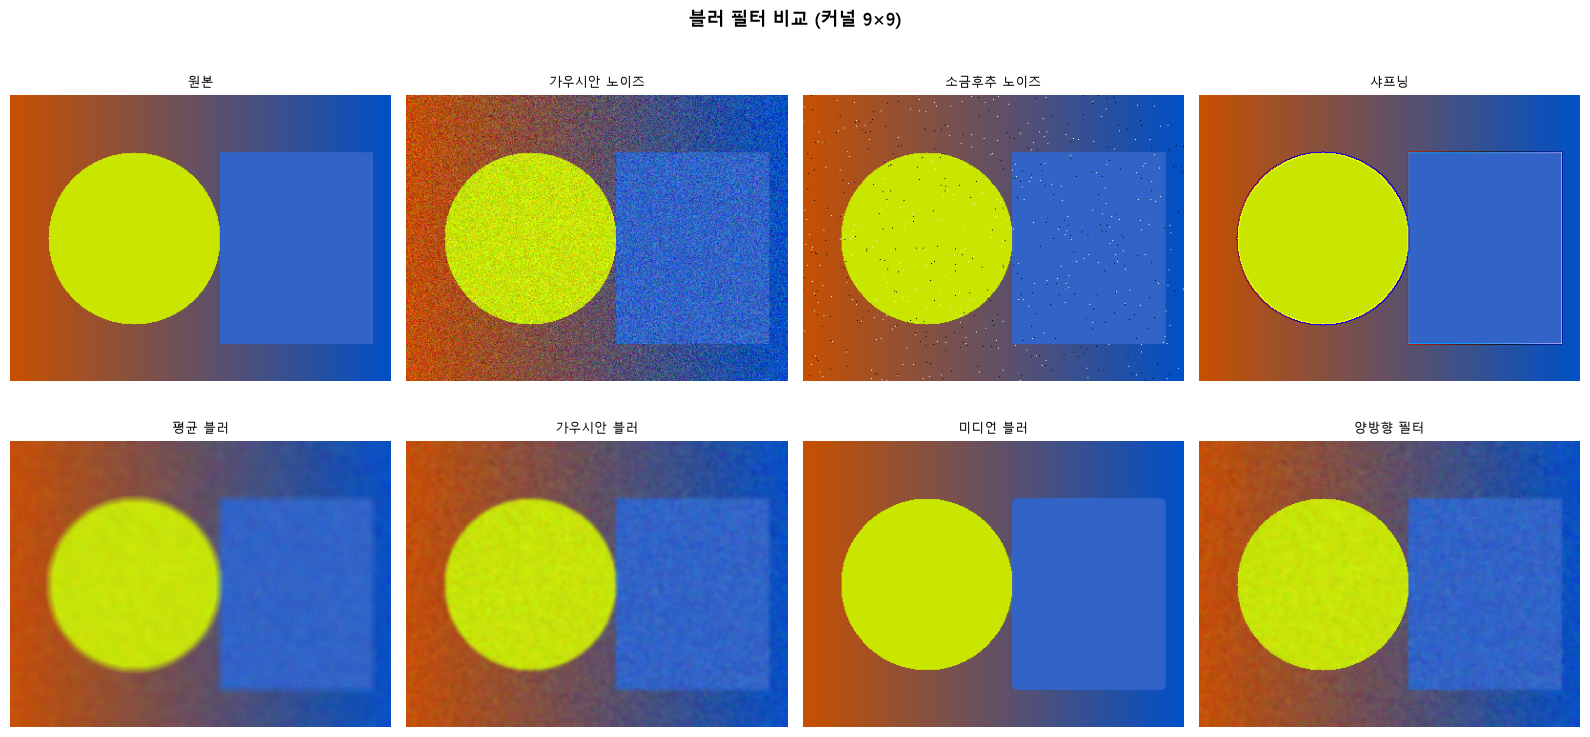

✅ 블러·샤프닝 완료!


In [94]:
"""  블러·샤프닝·노이즈 제거"""
import cv2  # 이미지 처리를 위한 OpenCV 라이브러리 불러오기
import numpy as np  # 행렬 연산 및 무작위 노이즈 생성을 위한 NumPy 불러오기
import matplotlib.pyplot as plt  # 시각화를 위한 Matplotlib 불러오기

# 1. 테스트용 깨끗한 원본 샘플 이미지 생성 함수 정의
def make_img():
    # 세로 300, 가로 400, 3채널(BGR) 크기의 도화지 생성
    img = np.zeros((300, 400, 3), dtype=np.uint8)
    
    # 가로 방향으로 BGR 색상 그라데이션 적용
    for x in range(400): 
        img[:, x] = [int(x / 400 * 200), 80, int((1 - x / 400) * 200)]
        
    # 샘플 이미지 위에 민트색 원과 주황/파란 계열 사각형 그리기
    cv2.circle(img, (130, 150), 90, (0, 230, 200), -1)       # 원 (중심: 130,150 / 반지름: 90)
    cv2.rectangle(img, (220, 60), (380, 260), (200, 100, 50), -1) # 사각형 (좌상단: 220,60 / 우하단: 380,260)
    return img

# 2. 깨끗한 원본 생성 및 노이즈(가우시안, 소금·후추) 생성
clean = make_img()

# 가우시안 노이즈 생성 (평균 0, 표준편차 25의 정규분포 무작위값 합성 후 0~255 범위를 벗어나지 않게 클리핑)
noise_g = np.clip(clean.astype(np.float32) + np.random.normal(0, 25, clean.shape), 0, 255).astype(np.uint8)

# 소금·후추(Salt & Pepper) 노이즈 생성 (무작위 300개 좌표에 흰색 점 255 및 검은색 점 0을 부여)
noise_sp = clean.copy()
sy, sx = [np.random.randint(0, i, 300) for i in clean.shape[:2]]  # 소금(흰 점) 노이즈 좌표 300개 무작위 추출
noise_sp[sy, sx] = 255
py, px = [np.random.randint(0, i, 300) for i in clean.shape[:2]]  # 후추(검은 점) 노이즈 좌표 300개 무작위 추출
noise_sp[py, px] = 0

# 3. 블러링 및 샤프닝 필터 커널 및 필터링 수행
ksize = (9, 9)  # 평균/가우시안 필터에 적용할 커널 크기 (9x9)

# 샤프닝 필터 커널 정의 (중심 가중치 9, 주변 가중치 -1로 경계선 강조)
kernel_sharp = np.array([[-1, -1, -1],
                         [-1,  9, -1],
                         [-1, -1, -1]])

blur_avg = cv2.blur(noise_g, ksize)                      # 평균 블러링 적용 (가우시안 노이즈 대상)
blur_gauss = cv2.GaussianBlur(noise_g, ksize, 0)         # 가우시안 블러링 적용 (가우시안 노이즈 대상)
blur_median = cv2.medianBlur(noise_sp, 9)               # 미디언 블러링 적용 (소금·후추 노이즈 대상 - 탁월한 제거 성능)
blur_bilat = cv2.bilateralFilter(noise_g, 9, 75, 75)    # 양방향 필터 적용 (가우시안 노이즈 대상 - 엣지 보존)

img_sharp = cv2.filter2D(clean, -1, kernel_sharp)        # 직접 정의한 샤프닝 커널을 이용하여 엣지 강조
blurred_us = cv2.GaussianBlur(clean, (0, 0), 3)         # 언샤프 마스킹을 위한 가우시안 블러 이미지
img_unsharp = cv2.addWeighted(clean, 1.5, blurred_us, -0.5, 0)  # 언샤프 마스킹: 원본과 블러 이미지를 가중 합성하여 날카롭게 표현

# 4. 시각화할 결과 데이터 배열 정의 (이미지 객체, 제목)
items = [
    (clean, "원본"),
    (noise_g, "가우시안 노이즈"),
    (noise_sp, "소금후추 노이즈"),
    (img_sharp, "샤프닝"),
    (blur_avg, "평균 블러"),
    (blur_gauss, "가우시안 블러"),
    (blur_median, "미디언 블러"),
    (blur_bilat, "양방향 필터")
]

# 5. Matplotlib 서브플롯 생성 (2행 4열 그리드, 전체 크기 16x8 인치)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("블러 필터 비교 (커널 9×9)", fontsize=13, fontweight="bold")  # 상단 전체 제목 설정

# 2행 4열의 각 축(axes.flat)에 순서대로 이미지를 매핑하여 시각화
for ax, (im, t) in zip(axes.flat, items):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))  # Matplotlib에 맞게 BGR -> RGB 변환 후 표시
    ax.set_title(t, fontsize=9)                     # 서브플롯 제목 설정
    ax.axis("off")                                  # 눈금 및 축 숨기기

# 6. 레이아웃 정돈 및 이미지 저장/출력
plt.tight_layout()  # 서브플롯 간 여백 자동 조절
plt.savefig("blur_demo.png", dpi=100, bbox_inches="tight")  # 결과 그래프를 파일로 저장
plt.show()  # 화면에 결과 창 출력

print("✅ 블러·샤프닝 완료!")

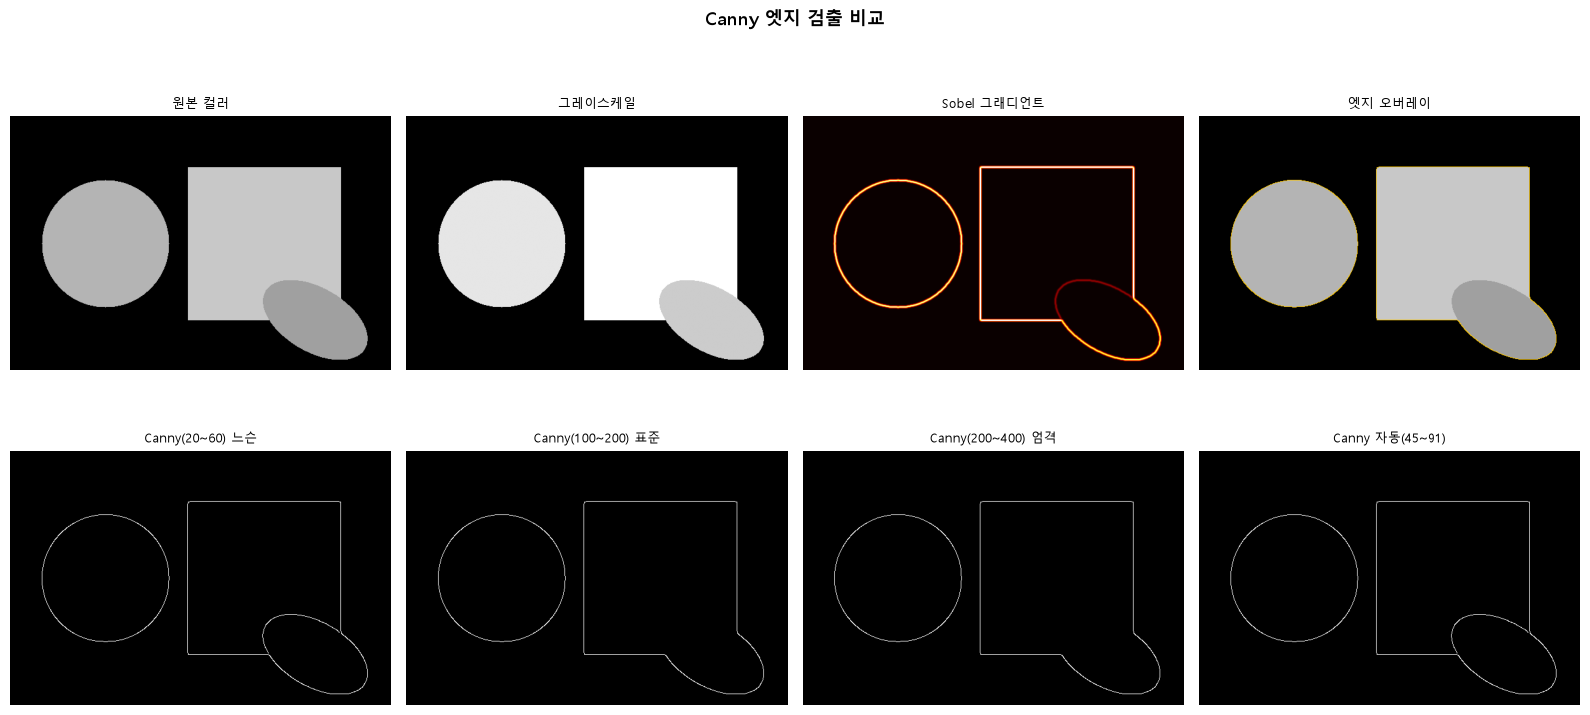

✅ Canny 엣지 검출 완료!


In [95]:
""" Canny 엣지 검출·Sobel 그래디언트"""
import cv2  # 이미지 처리를 위한 OpenCV 라이브러리 불러오기
import numpy as np  # 행렬 연산 및 배열 처리를 위한 NumPy 불러오기
import matplotlib.pyplot as plt  # 시각화를 위한 Matplotlib 불러오기

# 1. 테스트용 기하학 도형 이미지 생성 함수 정의
def make_img():
    # 세로 400, 가로 600, 3채널(BGR) 크기의 검은색 도화지 생성
    img = np.zeros((400, 600, 3), dtype=np.uint8)
    # 원, 사각형, 타원 도형 그리기 (다양한 경계선 및 엣지 테스트용)
    cv2.circle(img, (150, 200), 100, (180, 180, 180), -1)        # 원 (중심: 150,200 / 반지름: 100)
    cv2.rectangle(img, (280, 80), (520, 320), (200, 200, 200), -1) # 사각형 (좌상단: 280,80 / 우하단: 520,320)
    cv2.ellipse(img, (480, 320), (90, 50), 30, 0, 360, (160, 160, 160), -1) # 타원
    return img

# 2. 이미지 생성 및 전처리 (그레이스케일 변환 & 가우시안 블러 노이즈 제거)
img = make_img()  # 샘플 이미지 생성
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # 엣지 검출을 위해 BGR을 1채널 흑백(그레이스케일)으로 변환
blurred = cv2.GaussianBlur(gray, (5, 5), 0)  # Canny 연산 전, 잡음을 줄이기 위한 가우시안 블러링(5x5)

# 3. Canny 엣지 검출 - 임계값(Threshold)에 따른 민감도 테스트
edges_loose = cv2.Canny(blurred, 20, 60)     # 느슨한 임계값(20~60): 세밀하고 미세한 엣지까지 모두 검출
edges_normal = cv2.Canny(blurred, 100, 200)  # 표준 임계값(100~200): 일반적인 주요 윤곽선 검출
edges_strict = cv2.Canny(blurred, 200, 400)  # 엄격한 임계값(200~400): 명확하고 강한 엣지만 선별 검출

# Otsu(오츠) 이진화를 통한 자동 임계값(Threshold) 산출 및 Canny 적용
ot, _ = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
edges_auto = cv2.Canny(blurred, int(ot * 0.5), int(ot))  # 오츠 임계값 기반 하한(50%)/상한(100%) 자동 설정

# 4. Sobel 필터를 이용한 그래디언트(밝기 변화율) 크기 계산
sobelx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)  # x축 방향 미분 (수직 엣지 검출)
sobely = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)  # y축 방향 미분 (수평 엣지 검출)
# x, y 그래디언트의 벡터 크기(Magnitude) 계산 후 0~255 범위를 갖는 uint8 형식으로 정규화
magnitude = cv2.normalize(np.sqrt(sobelx**2 + sobely**2), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# 5. 원본 이미지 위에 검출된 표준 엣지 영역을 네온 주황색([0, 200, 255])으로 오버레이
overlay = img.copy()
overlay[edges_normal > 0] = [0, 200, 255]

# 6. 시각화할 데이터 및 옵션 배열 정의 (이미지, 제목, 컬러맵)
items = [
    (img, "원본 컬러", None),
    (gray, "그레이스케일", "gray"),
    (magnitude, "Sobel 그래디언트", "hot"),           # 그래디언트 크기를 열지도(hot) 컬러맵으로 표현
    (overlay, "엣지 오버레이", None),
    (edges_loose, "Canny(20~60) 느슨", "gray"),
    (edges_normal, "Canny(100~200) 표준", "gray"),
    (edges_strict, "Canny(200~400) 엄격", "gray"),
    (edges_auto, f"Canny 자동({int(ot*0.5)}~{int(ot)})", "gray")
]

# 7. Matplotlib 서브플롯 생성 (2행 4열 그리드, 전체 크기 16x8 인치)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Canny 엣지 검출 비교", fontsize=13, fontweight="bold")  # 상단 전체 제목 설정

# 2행 4열의 각 축(axes.flat)에 순서대로 이미지를 매핑하여 시각화
for ax, (im, t, cmap) in zip(axes.flat, items):
    # 컬러맵이 없는 경우(컬러/오버레이 이미지) BGR -> RGB 변환 수행
    disp = cv2.cvtColor(im, cv2.COLOR_BGR2RGB) if cmap is None else im
    ax.imshow(disp, cmap=cmap)  # 이미지 출력
    ax.set_title(t, fontsize=9)  # 서브플롯 제목 설정
    ax.axis("off")               # 눈금 및 축 숨기기

# 8. 레이아웃 정돈 및 이미지 저장/출력
plt.tight_layout()  # 플롯 간 여백 자동 조절
plt.savefig("canny_demo.png", dpi=100, bbox_inches="tight")  # 결과 그래프를 파일로 저장
plt.show()  # 화면에 결과 창 출력

print("✅ Canny 엣지 검출 완료!")